In [1]:
import json
import math
import os
from pathlib import Path
from pprint import pprint
import sys

path = "/home/lk3591/Documents/code/RawByteClf"
os.chdir(path)
if path not in sys.path:
	sys.path.insert(0, path)

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import transformers

from src.data.cfg import BODMAS_DIST_FILE
from src.learn.train import get_config
from src.utils import count_parameters, get_highest_path

Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/__init__.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/__init__.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/train.py'


2024-01-12 14:18:25,944	INFO util.py:159 -- Outdated packages:
  ipywidgets==7.6.5 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-01-12 14:18:26,030	INFO util.py:159 -- Outdated packages:
  ipywidgets==7.6.5 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/malconv.py'
Entered __file__='/home/lk3591/Documents/code/RawByteClf/src/learn/utils.py'


# Dataset

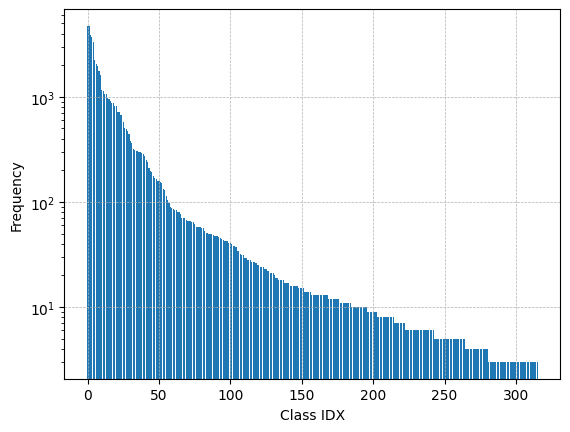

In [11]:
d = json.load(open(BODMAS_DIST_FILE, "r"))
for c in ("benign", "unknown", "Unknown"):
	d.pop(c, None)
d = {k: v for k, v in d.items() if v >= 3}

ticks = list(range(0, len(list(d.keys())), 50))

plt.bar(d.keys(), d.values())
plt.xticks(ticks, labels=[str(i) for i in ticks])
plt.yscale("log")
plt.xlabel("Class IDX")
plt.ylabel("Frequency")
plt.grid(which="major", axis="both", linestyle="--", linewidth=0.5)

In [112]:
def oversampled(t: float):
    # unnormalized probabilities for single draw
	p = [1 / math.pow(v, t) for v in d.values()]
	# normalized probabilities for single draw
	p = [x / sum(p) for x in p]
	# weighted liklihood for single draw
	p = [x * v for x, v in zip(p, d.values())]
	# number of draws in total
	f = max(d.values()) / max(p)
	return {k: int(v * f) for k, v in zip(d.keys(), p)}


def undersampled(t: float):
	p = [1 / math.pow(v, t) for v in d.values()]
	p = [x / sum(p) for x in p]
	p = [x * v for x, v in zip(p, d.values())]
	f = min(d.values()) / max(p)
	return {k: int(v * f) for k, v in zip(d.keys(), p)}

In [ ]:
undersampled(1 / 2)

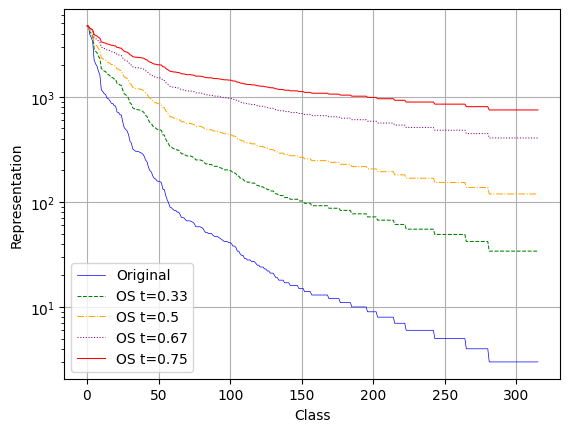

In [114]:
plt.plot(range(len(d.values())), d.values(), color="blue", label="Original", linewidth=.5)
colors = ["green", "orange", "purple", "red"]
styles = ["--", "-.", ":", "-"]
for t, c, s in zip([1/3, 1/2, 2/3, 3/4], colors, styles):
	d_o = oversampled(t)
	plt.plot(range(len(d_o.values())), d_o.values(), color=c, label=f"OS t={round(t, 2)}", linewidth=.75, linestyle=s)

plt.xlabel('Class')
plt.ylabel('Representation')
plt.yscale('log')
plt.legend()
plt.grid()

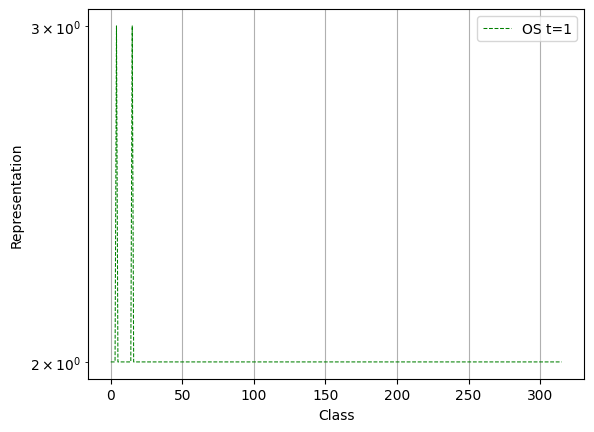

In [117]:
for t, c, s in zip([1/3, 1/2, 2/3, 3/4], colors, styles):
	d_u = undersampled(t)
	plt.plot(range(len(d_u.values())), d_u.values(), color=c, label=f"OS t={round(t, 2)}", linewidth=.75, linestyle=s)

plt.xlabel('Class')
plt.ylabel('Representation')
plt.yscale('log')
plt.legend()
plt.grid()

In [7]:
from src.learn.train import modify_positional_embeddings, get_model
import numpy as np
from torch.nn import Embedding


tokenizer = transformers.AutoTokenizer.from_pretrained("allenai/longformer-base-4096")


lengths = [2 ** i for i in range(10, 18)]
params_1 = []
params_2 = []

for max_length in lengths:
	config = get_config("longformer", tokenizer, max_length)
	config.vocab_size = 264
	model = get_model("clf", "longformer", config)
	params_1.append(count_parameters(model))
	params_2.append(count_parameters(model.longformer.embeddings.position_embeddings))

	# model.longformer.embeddings.position_embeddings = Embedding.from_pretrained(
	# 	model.longformer.embeddings.position_embeddings.weight, freeze=True
	# )

params_1 = np.array(params_1) / 1e6
params_2 = np.array(params_2) / 1e6
params_3 = params_1 - params_2

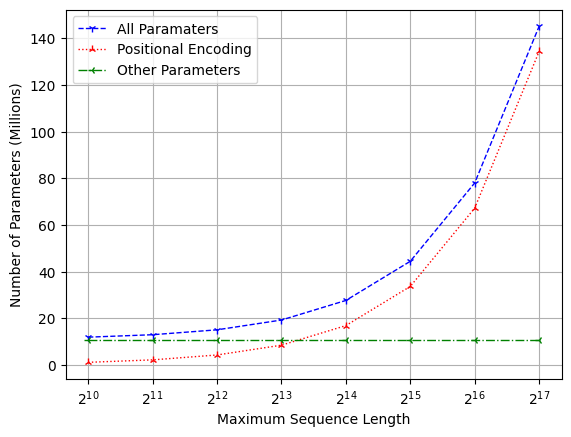

In [8]:
plt.plot(lengths, params_1, color="blue", label="All Paramaters", linewidth=1, marker="1", linestyle="--")
plt.plot(lengths, params_2, color="red", label="Positional Encoding", linewidth=1, marker="2", linestyle=":")
plt.plot(lengths, params_3, color="green", label="Other Parameters", linewidth=1, marker="3", linestyle="-.")

plt.ylabel("Number of Parameters (Millions)")
plt.xlabel("Maximum Sequence Length")

plt.xticks(lengths)
plt.xscale("log", base=2)

# ax2.set_ylabel("GPU Memory (GB)")
# ax2.set_yscale("log")
# ax2.set_yticks(16 * ax1.get_yticks() / 1e9)

plt.grid()
plt.legend()

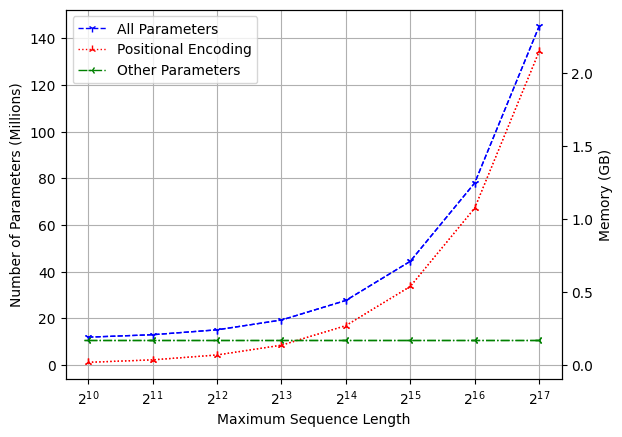

In [16]:
fig, ax1 = plt.subplots()

ax1.plot(lengths, params_1, color="blue", label="All Parameters", linewidth=1, marker="1", linestyle="--")
ax1.plot(lengths, params_2, color="red", label="Positional Encoding", linewidth=1, marker="2", linestyle=":")
ax1.plot(lengths, params_3, color="green", label="Other Parameters", linewidth=1, marker="3", linestyle="-.")

ax1.set_xlabel("Maximum Sequence Length")
ax1.set_ylabel("Number of Parameters (Millions)", color="black")
ax1.tick_params("y", colors="black")
ax1.set_xticks(lengths)
ax1.set_xscale("log", base=2)

# Create a twin Axes for the second y-axis
ax2 = ax1.twinx()

# Additional data for the second y-axis
mem_1 = (16 * params_1 * 1e6) / 1e9
mem_2 = (16 * params_2 * 1e6) / 1e9
mem_3 = (16 * params_3 * 1e6) / 1e9

# Plot on the second y-axis
ax2.plot(lengths, mem_1, color="blue", label="All Parameters", linewidth=1, marker="1", linestyle="--")
ax2.plot(lengths, mem_2, color="red", label="Positional Encoding", linewidth=1, marker="2", linestyle=":")
ax2.plot(lengths, mem_3, color="green", label="Other Parameters", linewidth=1, marker="3", linestyle="-.")

ax2.set_ylabel("Memory (GB)", color="black")
ax2.tick_params("y", colors="black")

# Show the legend
ax1.grid()
ax1.legend(loc="upper left")

## Plotting Performance CLF

In [4]:
METRIC_MAP = [
    ("eval_loss", ""),
    ("eval_accuracy", "accuracy"), 
    ("eval_f1-macro", "f1"),
    ("eval_f1-micro", "f1")
]


def trainer_state_to_log_history(trainer_state: dict):
    return trainer_state["log_history"]


def log_history_to_per_epoch_performance(log_history: list[dict]) -> list[dict]:
    validation_runs = [d for d in log_history if "eval_loss" in d]
    for epoch in range(len(validation_runs)):
        v = validation_runs[epoch]
        d = {"epoch": epoch + 1}

        for outer, inner in METRIC_MAP:
            if isinstance(v[outer], (int, float)):
                d[outer] = v[outer]
            elif isinstance(v[outer], dict):
                d[outer] = v[outer][inner]
            else:
                raise RuntimeError()

        validation_runs[epoch] = d
    return validation_runs


ROOT = Path("/home/lk3591/Documents/code/RawByteClf/output/longformer/")


experiments = {
    # "16k": ROOT / "16384/clf/4/False/False/False",
    # "16k-mlm": ROOT / "16384/mlm/4/best/16384/clf/4/False/False/False",
    # "16k-mlm-frozen": ROOT / "16384/mlm/4/best/16384/clf/4/True/True/False",
    "longformer@2^16": ROOT / "65536/clf/4/False/False/False",
    "longformer-mlm@2^16": ROOT / "16384/mlm/4/best/65536/clf/4/False/True/False",
    # "64k-mlm-frozen": ROOT / "16384/mlm/4/best/65536/clf/4/True/True/False",
    "malconvgct@2^16": Path("/home/lk3591/Documents/code/RawByteClf/output/malconvgct/65536/clf/1/False/False/False"),
    "malconvgct@2^20": Path("/home/lk3591/Documents/code/RawByteClf/output/malconvgct/1048576/clf/1/False/False/False"),
    "mymalconv@2^16": Path("/home/lk3591/Documents/code/RawByteClf/output/mymalconv/65536/clf/1/False/False/False"),
    # "mymalconv@2^20": Path("/home/lk3591/Documents/code/RawByteClf/output/mymalconv/1048576/clf/1/False/False/False"),
}
for p in experiments.values():
    assert p.exists(), p.as_posix() + " does not exist"


for k in experiments:
    print(k)
    checkpoints = [p for p in (experiments[k] / "checkpoints").glob("checkpoint-*")]
    last_checkpoint = get_highest_path(checkpoints, lstrip="checkpoint-")
    trainer_state_file = last_checkpoint / "trainer_state.json"
    trainer_state = json.load(open(trainer_state_file, "r"))
    log_history = trainer_state_to_log_history(trainer_state)
    experiments[k] = log_history_to_per_epoch_performance(log_history)

longformer@2^16
longformer-mlm@2^16
malconvgct@2^16
malconvgct@2^20
mymalconv@2^16


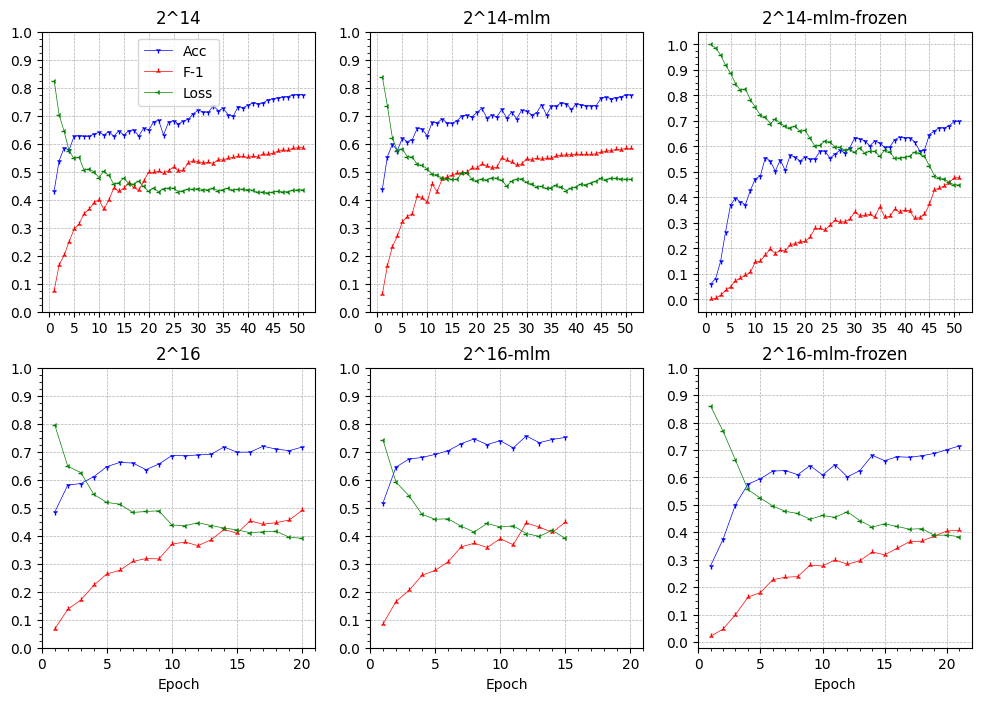

In [13]:
def epochs(log):
    return [d["epoch"] for d in log]

def accuracy(log):
	return [d["eval_accuracy"] for d in log]

def f1(log):
	return [d["eval_f1-macro"] for d in log]

def loss(log, norm: bool = True, max_val: float = None, min_val: float = None):
	arr = [d["eval_loss"] for d in log]
	max_val = max(arr) if max_val is None else max_val
	min_val = min(arr) if min_val is None else min_val
	if norm:
		return min_max_normalize(arr, min_val, max_val)
	return arr

def min_max_normalize(arr: list[float], min_val: float, max_val: float):
    return [(x - min_val) / (max_val - min_val) for x in arr]


COLOR_AC = "blue"
COLOR_F1 = "red"
COLOR_LS = "green"
MARKER_AC = "1"
MARKER_F1 = "2"
MARKER_LS = "3"
LINEWIDTH = 0.5
MARKERSIZE = 4

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
upper_xlim = 0
lower_xlim = 0
max_loss = max([max(loss(experiments[k], norm=False)) for k in experiments])

log = experiments["16k"]
upper_xlim = max(upper_xlim, max(epochs(log)))
axes[0, 0].plot(epochs(log), accuracy(log), color=COLOR_AC, marker=MARKER_AC, linewidth=LINEWIDTH, markersize=MARKERSIZE, label="Acc")
axes[0, 0].plot(epochs(log), f1(log), color=COLOR_F1, marker=MARKER_F1, linewidth=LINEWIDTH, markersize=MARKERSIZE, label="F-1")
axes[0, 0].plot(epochs(log), loss(log, max_val=max_loss, min_val=0), color=COLOR_LS, marker=MARKER_LS, linewidth=LINEWIDTH, markersize=MARKERSIZE, label="Loss")
axes[0, 0].set_title("2^14")

log = experiments["16k-mlm"]
upper_xlim = max(upper_xlim, max(epochs(log)))
axes[0, 1].plot(epochs(log), accuracy(log), color=COLOR_AC, marker=MARKER_AC, markersize=MARKERSIZE, linewidth=LINEWIDTH)
axes[0, 1].plot(epochs(log), f1(log), color=COLOR_F1, marker=MARKER_F1, markersize=MARKERSIZE, linewidth=LINEWIDTH)
axes[0, 1].plot(epochs(log), loss(log, max_val=max_loss, min_val=0), color=COLOR_LS, marker=MARKER_LS, linewidth=LINEWIDTH, markersize=MARKERSIZE)
axes[0, 1].set_title("2^14-mlm")

log = experiments["16k-mlm-frozen"]
upper_xlim = max(upper_xlim, max(epochs(log)))
axes[0, 2].plot(epochs(log), accuracy(log), color=COLOR_AC, marker=MARKER_AC, markersize=MARKERSIZE, linewidth=LINEWIDTH)
axes[0, 2].plot(epochs(log), f1(log), color=COLOR_F1, marker=MARKER_F1, markersize=MARKERSIZE, linewidth=LINEWIDTH)
axes[0, 2].plot(epochs(log), loss(log, max_val=max_loss, min_val=0), color=COLOR_LS, marker=MARKER_LS, linewidth=LINEWIDTH, markersize=MARKERSIZE)
axes[0, 2].set_title("2^14-mlm-frozen")

log = experiments["64k"]
lower_xlim = max(lower_xlim, max(epochs(log)))
axes[1, 0].plot(epochs(log), accuracy(log), color=COLOR_AC, marker=MARKER_AC, markersize=MARKERSIZE, linewidth=LINEWIDTH)
axes[1, 0].plot(epochs(log), f1(log), color=COLOR_F1, marker=MARKER_F1, markersize=MARKERSIZE, linewidth=LINEWIDTH)
axes[1, 0].plot(epochs(log), loss(log, max_val=max_loss, min_val=0), color=COLOR_LS, marker=MARKER_LS, linewidth=LINEWIDTH, markersize=MARKERSIZE)
axes[1, 0].set_title("2^16")

log = experiments["64k-mlm"]
lower_xlim = max(lower_xlim, max(epochs(log)))
axes[1, 1].plot(epochs(log), accuracy(log), color=COLOR_AC, marker=MARKER_AC, markersize=MARKERSIZE, linewidth=LINEWIDTH)
axes[1, 1].plot(epochs(log), f1(log), color=COLOR_F1, marker=MARKER_F1, markersize=MARKERSIZE, linewidth=LINEWIDTH)
axes[1, 1].plot(epochs(log), loss(log, max_val=max_loss, min_val=0), color=COLOR_LS, marker=MARKER_LS, linewidth=LINEWIDTH, markersize=MARKERSIZE)
axes[1, 1].set_title("2^16-mlm")

log = experiments["64k-mlm-frozen"]
lower_xlim = max(lower_xlim, max(epochs(log)))
axes[1, 2].plot(epochs(log), accuracy(log), color=COLOR_AC, marker=MARKER_AC, markersize=MARKERSIZE, linewidth=LINEWIDTH)
axes[1, 2].plot(epochs(log), f1(log), color=COLOR_F1, marker=MARKER_F1, markersize=MARKERSIZE, linewidth=LINEWIDTH)
axes[1, 2].plot(epochs(log), loss(log, max_val=max_loss, min_val=0), color=COLOR_LS, marker=MARKER_LS, linewidth=LINEWIDTH, markersize=MARKERSIZE)
axes[1, 2].set_title("2^16-mlm-frozen")


for i in [0, 1]:
    for j in [0, 1, 2]:
        axes[i, j].set_yticks(np.arange(0, 1.1, 0.1))
        axes[i, j].set_yticks(np.arange(0, 1.025, 0.025), minor=True)


for j in [0, 1, 2]:
	axes[0, j].set_xticks(range(0, upper_xlim + 1, 5))
	axes[0, j].set_xticks(range(0, upper_xlim + 1, 1), minor=True)
	axes[1, j].set_xticks(range(0, lower_xlim + 1, 5))
	axes[1, j].set_xticks(range(0, lower_xlim + 1, 1), minor=True)


for i in [0, 1]:
    for j in [0, 1, 2]:
        axes[i, j].grid(which="major", axis="both", linestyle="--", linewidth=0.5)


for j in [0, 1, 2]:
	axes[1, j].set_xlabel("Epoch")


axes[0, 0].legend(loc="upper center")

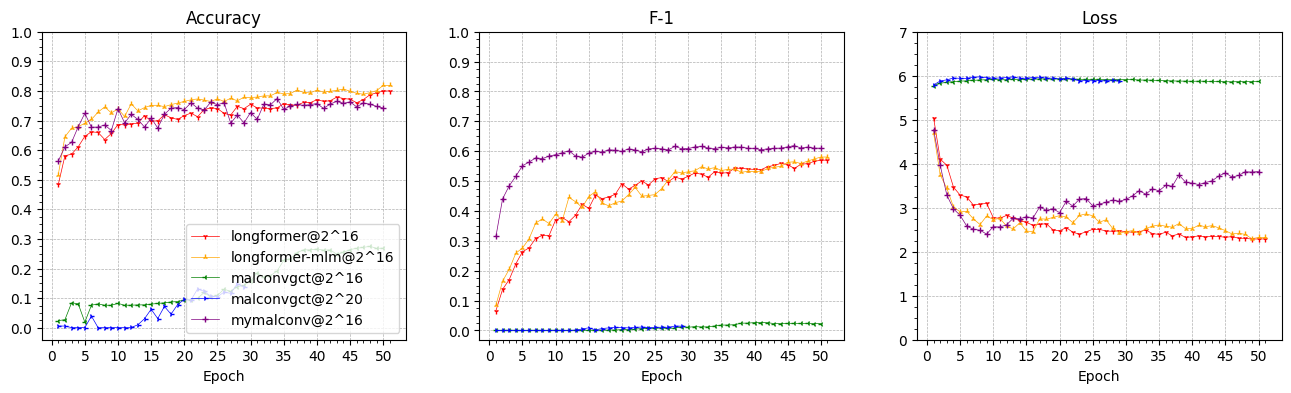

In [5]:
def epochs(log):
    return list(range(1, len(log) + 1))

def accuracy(log):
	return [d["eval_accuracy"] for d in log]

def f1(log):
	return [d["eval_f1-macro"] for d in log]

def loss(log, norm: bool = True, max_val: float = None, min_val: float = None):
	arr = [d["eval_loss"] for d in log]
	max_val = max(arr) if max_val is None else max_val
	min_val = min(arr) if min_val is None else min_val
	if norm:
		return min_max_normalize(arr, min_val, max_val)
	return arr

def min_max_normalize(arr: list[float], min_val: float, max_val: float):
    return [(x - min_val) / (max_val - min_val) for x in arr]


# LABELS = [
#     "M1",
#     "M2",
#     #"M3",
#     "M4",
#     "M5",
#     #"M6",
#     "M7",
#     "M8",
# ]
LABELS = list(experiments.keys())
COLORS = [
    "red",
    "orange",
    #"yellow",
    "green",
    "blue",
    #"purple",
    "purple",
    "pink",
]
MARKERS = ["1", "2", "3", "4", "+", "x", "o"]

LINEWIDTH = 0.5
MARKERSIZE = 4

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
xlim = 0
max_loss = max([max(loss(experiments[k], norm=False)) for k in experiments])

for log, label, color, marker in zip(experiments.values(), LABELS, COLORS, MARKERS):
	xlim = max(xlim, max(epochs(log)))
	axes[0].plot(epochs(log), accuracy(log), color=color, marker=marker, linewidth=LINEWIDTH, markersize=MARKERSIZE, label=label)
	axes[1].plot(epochs(log), f1(log), color=color, marker=marker, linewidth=LINEWIDTH, markersize=MARKERSIZE, label=label)
	axes[2].plot(epochs(log), loss(log, norm=False), color=color, marker=marker, linewidth=LINEWIDTH, markersize=MARKERSIZE, label=label)

axes[0].set_title("Accuracy")
axes[1].set_title("F-1")
axes[2].set_title("Loss")


for j in [0, 1]:
	axes[j].set_yticks(np.arange(0, 1.1, 0.1))
	axes[j].set_yticks(np.arange(0, 1.025, 0.025), minor=True)
axes[2].set_yticks(np.arange(0, 7.1, 1))
axes[2].set_yticks(np.arange(0, 7.1, 0.25), minor=True)

for j in [0, 1, 2]:
	axes[j].set_xticks(range(0, xlim + 1, 5))
	axes[j].set_xticks(range(0, xlim + 1, 1), minor=True)


for j in [0, 1, 2]:
	axes[j].grid(which="major", axis="both", linestyle="--", linewidth=0.5)


for j in [0, 1, 2]:
	axes[j].set_xlabel("Epoch")


axes[0].legend(loc="lower right")

# Plotting Performance MLM

In [16]:
ROOT = Path("/home/lk3591/Documents/code/RawByteClf/output/")
TAIL = Path("16384/mlm/4")

METRIC_MAP = [
    ("eval_loss", ""),
]

def log_history_to_per_epoch_performance(log_history: list[dict]) -> list[dict]:
    logging_runs = []
    validation_runs = []
    for d in log_history:
        if "eval_loss" in d:
            logging_runs.append(prev)
            validation_runs.append(d)
        prev = d

    for i in range(len(validation_runs)):
        v = validation_runs[i]
        d = {"step": v["step"]}

        for outer, inner in METRIC_MAP:
            if isinstance(v[outer], (int, float)):
                d[outer] = v[outer]
            elif isinstance(v[outer], dict):
                d[outer] = v[outer][inner]
            else:
                raise RuntimeError()

        validation_runs[i] = d
        validation_runs[i]["loss"] = logging_runs[i]["loss"]
    
    return validation_runs

experiments = {
    "tuned": ROOT / "longformer" / TAIL,
    "untuned": ROOT /"longformer_untuned_hparams" / TAIL
}
for p in experiments.values():
    assert p.exists(), p.as_posix() + " does not exist"

for k in experiments:
    print(k)
    if (log_history_file := experiments[k] / "log_history.json").exists():
        log_history = json.load(open(log_history_file, "r"))
        experiments[k] = log_history_to_per_epoch_performance(log_history)
        continue
    checkpoints = [p for p in (experiments[k] / "checkpoints").glob("checkpoint-*")]
    last_checkpoint = get_highest_path(checkpoints, lstrip="checkpoint-")
    trainer_state_file = last_checkpoint / "trainer_state.json"
    trainer_state = json.load(open(trainer_state_file, "r"))
    log_history = trainer_state_to_log_history(trainer_state)
    experiments[k] = log_history_to_per_epoch_performance(log_history)

tuned
untuned


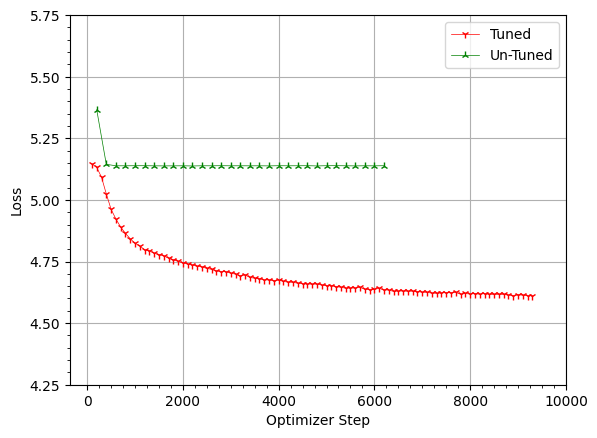

In [18]:
S = 30

log = experiments["tuned"]
steps = [d["step"] for d in log]
eval_losses = [d["eval_loss"] for d in log]
tr_losses = [d["loss"] for d in log]
plt.plot(steps, eval_losses, color="red", marker="1", label="Tuned", linewidth=0.5)

log = experiments["untuned"]
steps = [d["step"] for d in log]
eval_losses = [d["eval_loss"] for d in log]
tr_losses = [d["loss"] for d in log]
plt.plot(steps, eval_losses, color="green", marker="2", label="Un-Tuned", linewidth=0.5)


plt.xlabel("Optimizer Step")
plt.ylabel("Loss")

plt.xticks(list(range(0, 10001, 2000)), minor=False)
plt.xticks(list(range(0, 10001, 250)), minor=True)

plt.ylim(4.25, 5.75)
plt.yticks(np.arange(4.25, 5.751, 0.25), minor=False)
plt.yticks(np.arange(4.25, 5.751, 0.05), minor=True)

plt.legend()
plt.grid()

# Test Set CLF

In [9]:
ROOT = Path("/home/lk3591/Documents/code/RawByteClf/output/longformer")
TAIL = Path("test_results/results.json")

experiments = {
    "16k": ROOT / "16384/clf/4/False/False/False" / TAIL,
    "16k-mlm": ROOT / "16384/mlm/4/best/16384/clf/4/False/False/False" / TAIL,
    #"16k-mlm-frozen": ROOT / "16384/mlm/4/best/16384/clf/4/True/True/False" / TAIL,
    "64k": ROOT / "65536/clf/4/False/False/False" / TAIL,
    "64k-mlm": ROOT / "16384/mlm/4/best/65536/clf/4/False/True/False" / TAIL,
    #"64k-mlm-frozen": ROOT / "16384/mlm/4/best/65536/clf/4/True/True/False" / TAIL,
    "64k-gct": Path("/home/lk3591/Documents/code/RawByteClf/output/malconvgct/65536/clf/1/False/False/False") / TAIL
}
for p in experiments.values():
    print(p.exists(), p)

experiments = {k: json.load(open(v)) for k, v in experiments.items() if v.exists()}
pprint(experiments)

True /home/lk3591/Documents/code/RawByteClf/output/longformer/16384/clf/4/False/False/False/test_results/results.json
True /home/lk3591/Documents/code/RawByteClf/output/longformer/16384/mlm/4/best/16384/clf/4/False/False/False/test_results/results.json
True /home/lk3591/Documents/code/RawByteClf/output/longformer/65536/clf/4/False/False/False/test_results/results.json
True /home/lk3591/Documents/code/RawByteClf/output/longformer/16384/mlm/4/best/65536/clf/4/False/True/False/test_results/results.json
True /home/lk3591/Documents/code/RawByteClf/output/malconvgct/65536/clf/1/False/False/False/test_results/results.json
{'16k': {'test_accuracy': 0.7595042706414336,
         'test_f1-macro': 0.5365726002186519,
         'test_f1-micro': 0.7595042706414336,
         'test_loss': 3.285449266433716,
         'test_runtime': 292.6706,
         'test_samples_per_second': 20.402,
         'test_ss_accuracy': 0.42857142857142855,
         'test_ss_f1-macro': 0.2830188679245283,
         'test_ss_f1

In [12]:
columns = {
	"test_accuracy": "Accuracy",
	"test_f1-macro": "F-1",
	"test_ss_accuracy": "SS Accuracy",
	"test_ss_f1-macro": "SS F-1",
}
index = {
	"16k": "M1",
	"16k-mlm": "M2",
	#"16k-mlm-frozen": "M3",
	"64k": "M4",
	"64k-mlm": "M5",
	#"64k-mlm-frozen": "M6",
	"64k-gct": "M7",
}

df = pd.DataFrame(experiments).T.rename(columns=columns, index=index)[columns.values()]
df

,Accuracy,F-1,SS Accuracy,SS F-1
M1,0.759504,0.536573,0.428571,0.283019
M2,0.738235,0.524879,0.400000,0.269231
M4,0.786803,0.519474,0.285714,0.188679
M5,0.795679,0.540557,0.314286,0.203704
M7,0.022442,0.000488,0.000000,0.000000


In [13]:
print(df.to_latex())

\begin{tabular}{lrrrr}
\toprule
 & Accuracy & F-1 & SS Accuracy & SS F-1 \\
\midrule
M1 & 0.759504 & 0.536573 & 0.428571 & 0.283019 \\
M2 & 0.738235 & 0.524879 & 0.400000 & 0.269231 \\
M4 & 0.786803 & 0.519474 & 0.285714 & 0.188679 \\
M5 & 0.795679 & 0.540557 & 0.314286 & 0.203704 \\
M7 & 0.022442 & 0.000488 & 0.000000 & 0.000000 \\
\bottomrule
\end{tabular}



# Eval HRRFormer for Text Classification

Text(0.5, 1.0, 'Masked Language Modeling ELI5')

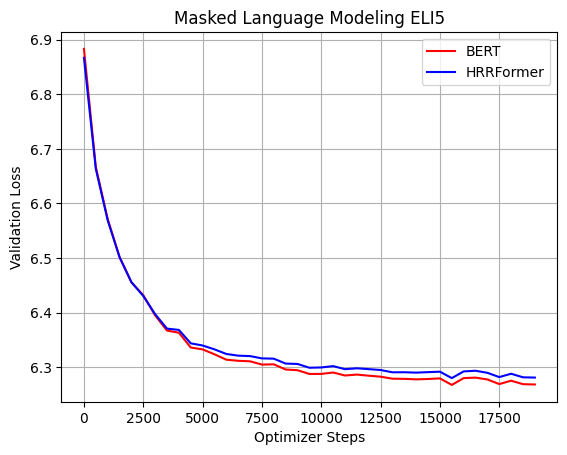

In [11]:
from src.analysis import process_trainer_state
import numpy as np
from pprint import pprint

head = Path("/home/lk3591/Documents/code/RawByteClf/tmp/mlm")
tail = "checkpoint-9750/trainer_state.json"
bert_validation_reports, _ = process_trainer_state(head / "bert" / tail)
bert_losses = [r["eval_loss"] for r in bert_validation_reports]
hrr_validation_reports, _ = process_trainer_state(head / "hrr" / tail)
hrr_losses = [r["eval_loss"] for r in hrr_validation_reports]

steps = np.arange(0, len(bert_validation_reports), 1) * 500

plt.plot(steps, bert_losses, color="red", label="BERT")
plt.plot(steps, hrr_losses, color="blue", label="HRRFormer")

plt.grid()
plt.legend()
plt.ylabel("Validation Loss")
plt.xlabel("Optimizer Steps")
plt.title("Masked Language Modeling ELI5")

Text(0.5, 1.0, 'Text Classification AG-News')

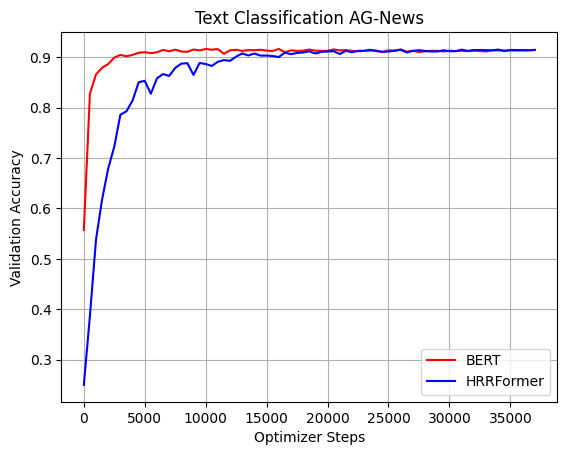

In [12]:
head = Path("/home/lk3591/Documents/code/RawByteClf/tmp/clf")
tail = "checkpoint-18750/trainer_state.json"
bert_validation_reports, _ = process_trainer_state(head / "bert" / tail)
bert_losses = [r["eval_accuracy"] for r in bert_validation_reports]
hrr_validation_reports, _ = process_trainer_state(head / "hrr" / tail)
hrr_losses = [r["eval_accuracy"] for r in hrr_validation_reports]

steps = np.arange(0, len(bert_validation_reports), 1) * 500

plt.plot(steps, bert_losses, color="red", label="BERT")
plt.plot(steps, hrr_losses, color="blue", label="HRRFormer")

plt.grid()
plt.legend()
plt.ylabel("Validation Accuracy")
plt.xlabel("Optimizer Steps")
plt.title("Text Classification AG-News")

# Weight Analysis

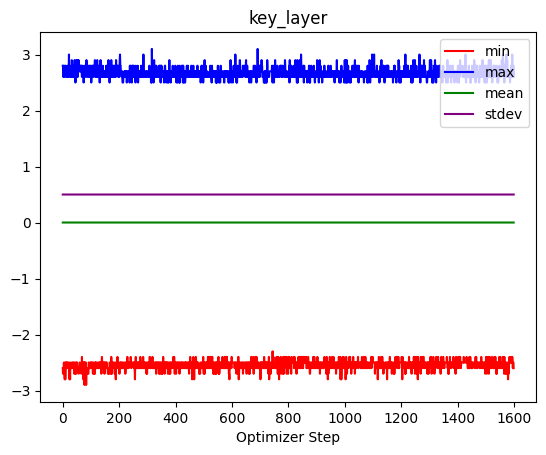

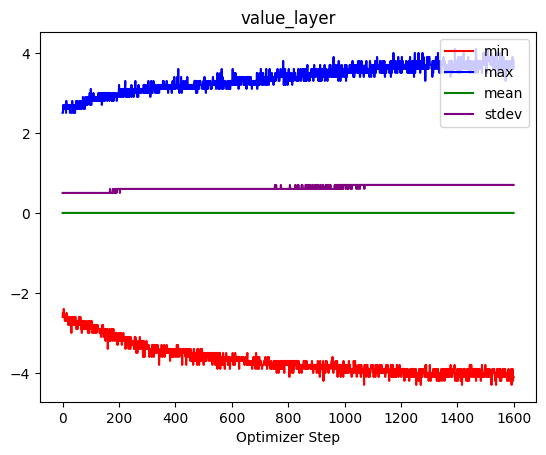

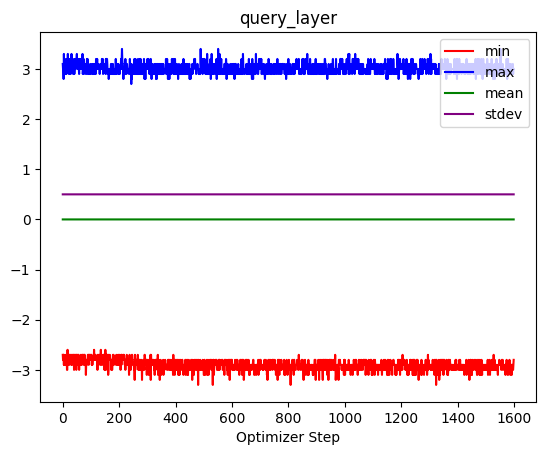

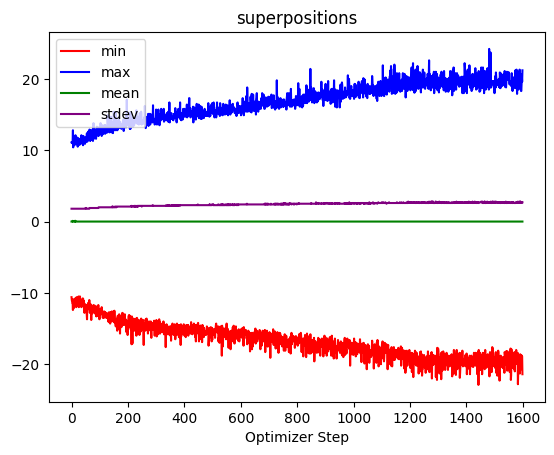

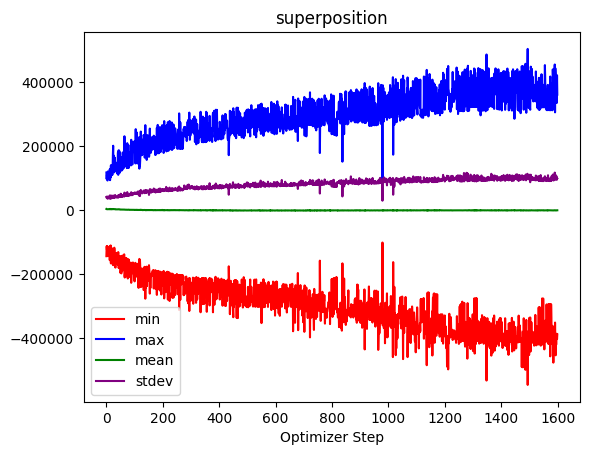

In [27]:
root = Path("./tmp/weight_analysis")
variables = [
    "key_layer",
    "value_layer",
    "query_layer",
    "superpositions",
    "superposition",
    "value_approx",
    "attention_scores",
]


def get_path(learning_rate="1e-3", weight_decay="0.0", max_grad_norm="1.0", warmup_ratio="0.0"):
    return root / f"{learning_rate}/{weight_decay}/{max_grad_norm}/{warmup_ratio}"


learning_rate="1e-3"
weight_decay="0.0"
max_grad_norm="1.0"
warmup_ratio="0.0"
path = get_path(learning_rate, weight_decay, max_grad_norm, warmup_ratio)


for v in variables:
    if v in ("value_approx", "attention_scores"):
        continue
    df = pd.read_csv(path / f"{v}.csv")
    plt.figure()
    plt.plot(df.index.tolist(), df["min"], color="red", label="min")
    plt.plot(df.index.tolist(), df["max"], color="blue", label="max")
    plt.plot(df.index.tolist(), df["mean"], color="green", label="mean")
    plt.plot(df.index.tolist(), df["stdev"], color="purple", label="stdev")
    plt.legend()
    plt.title(v)
    plt.xlabel("Optimizer Step")
    plt.show()

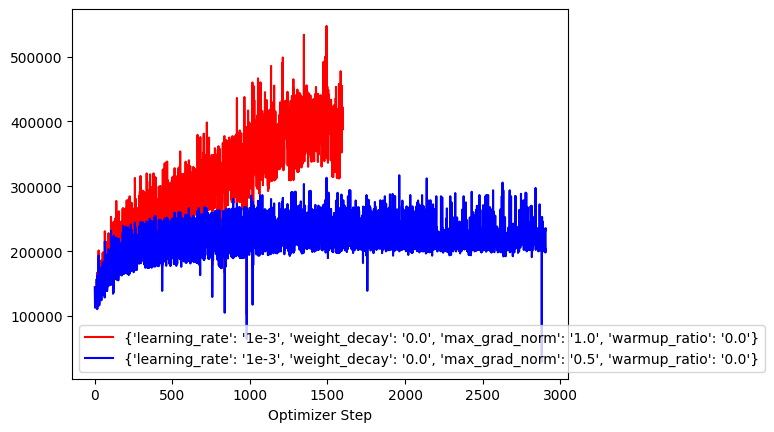

In [42]:
experiments = [
	{"learning_rate": "1e-4", "weight_decay": "0.001", "max_grad_norm": "1.0", "warmup_ratio": "0.0"},
	{"learning_rate": "1e-4", "weight_decay": "0.01", "max_grad_norm": "1.0", "warmup_ratio": "0.0"},
	{"learning_rate": "1e-4", "weight_decay": "0.1", "max_grad_norm": "1.0", "warmup_ratio": "0.0"},
	{"learning_rate": "1e-4", "weight_decay": "0.001", "max_grad_norm": "0.75", "warmup_ratio": "0.0"},
	{"learning_rate": "1e-4", "weight_decay": "0.01", "max_grad_norm": "0.75", "warmup_ratio": "0.0"},
	{"learning_rate": "1e-4", "weight_decay": "0.1", "max_grad_norm": "0.75", "warmup_ratio": "0.0"},
	{"learning_rate": "1e-4", "weight_decay": "0.001", "max_grad_norm": "0.5", "warmup_ratio": "0.0"},
	{"learning_rate": "1e-4", "weight_decay": "0.01", "max_grad_norm": "0.5", "warmup_ratio": "0.0"},
	{"learning_rate": "1e-4", "weight_decay": "0.1", "max_grad_norm": "0.5", "warmup_ratio": "0.0"},
	{"learning_rate": "1e-4", "weight_decay": "0.001", "max_grad_norm": "1.0", "warmup_ratio": "0.1"},
	{"learning_rate": "1e-4", "weight_decay": "0.01", "max_grad_norm": "1.0", "warmup_ratio": "0.1"},
	{"learning_rate": "1e-4", "weight_decay": "0.1", "max_grad_norm": "1.0", "warmup_ratio": "0.1"},
	{"learning_rate": "1e-4", "weight_decay": "0.001", "max_grad_norm": "0.75", "warmup_ratio": "0.1"},
	{"learning_rate": "1e-4", "weight_decay": "0.01", "max_grad_norm": "0.75", "warmup_ratio": "0.1"},
	{"learning_rate": "1e-4", "weight_decay": "0.1", "max_grad_norm": "0.75", "warmup_ratio": "0.1"},
	{"learning_rate": "1e-4", "weight_decay": "0.001", "max_grad_norm": "0.5", "warmup_ratio": "0.1"},
	{"learning_rate": "1e-4", "weight_decay": "0.01", "max_grad_norm": "0.5", "warmup_ratio": "0.1"},
	{"learning_rate": "1e-4", "weight_decay": "0.1", "max_grad_norm": "0.5", "warmup_ratio": "0.1"},
]

colors = {
	"0.001": "red",
	"0.01": "blue",
	"0.1": "green",
}
markers = {
	"1.0": "1",
	"0.75": "2",
	"0.5": "3",
}
linestyles = {
	"0.0": "--",
	"0.1": "-.",
}

for i, (e, c) in enumerate(zip(experiments, colors)):
	path = get_path(**e)
	df = pd.read_csv(path / f"superposition.csv")
	largest = [max(x, y) for x, y in zip(df["max"].abs(), df["min"].abs())]
	plt.plot(df.index.tolist(), largest, color=c, label=str(e))
	plt.xlabel("Optimizer Step")
	plt.legend()